<a href="https://colab.research.google.com/github/lfrp14/Portifolio-pessoal/blob/main/Detec%C3%A7%C3%A3o_de_Fraude_de_cart%C3%A3o_de_credito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

💳 Detecção de Fraude em Cartões de Crédito: Uma Abordagem Alternativa no Kaggle
A detecção de fraudes em transações financeiras é um dos maiores desafios da Ciência de Dados, principalmente devido ao extremo desbalanceamento dos dados (onde as fraudes representam uma fração mínima do total de transações).

Utilizando como base o famoso conjunto de dados de Detecção de Fraude em Cartão de Crédito disponível no Kaggle (plataforma que funciona como o principal ponto de encontro e portfólio para cientistas de dados no mundo ), decidi explorar uma abordagem metodológica diferente da solução proposta originalmente pelo autor do notebook de referência.

link do problema no kaggle:https://www.kaggle.com/code/elvisacaciobarbosa/detec-o-de-fraude-no-cart-o-de-cr-dito

In [1]:
#Importando todas as bibliotecas
import pandas as pd
from sklearn import model_selection
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_selection import mutual_info_classif
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix



In [2]:
#Analisando o dataframe
df = pd.read_csv('/content/creditcard.csv')
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


Análise da Variável Alvo


In [3]:
Fraude = len(df[df.Class == 1])
Normal = len(df[df.Class == 0])

print('fraude :', Fraude)
print('Normal :', Normal)



fraude : 492
Normal : 284315


Como observado, a base de dados apresenta um alto grau de desbalanceamento, um cenário típico em problemas de detecção de fraude em cartões de crédito. Consequentemente, a metodologia adotada deve ser adaptada para mitigar o viés da classe majoritária, diferindo substancialmente das abordagens utilizadas em conjuntos de dados balanceados.

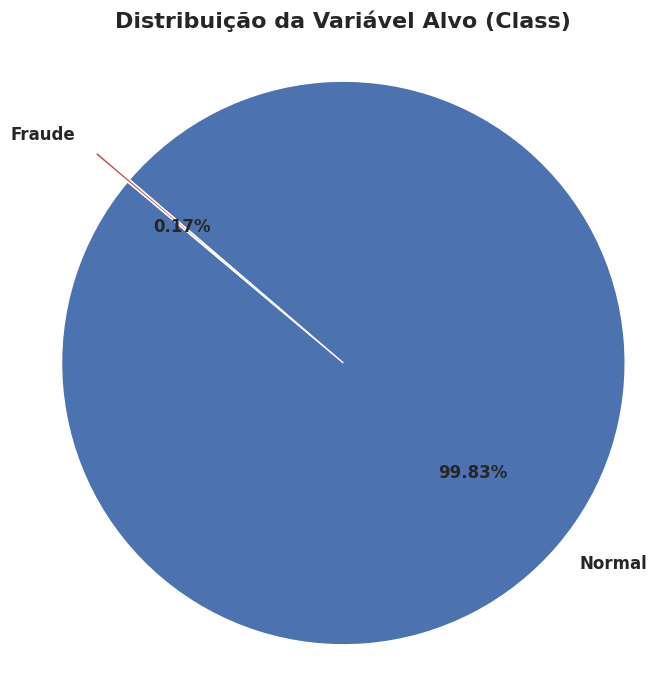

Aqui separamos as features e as target

In [4]:
X = df.iloc[:,2:-2]
y = df['Class']

In [5]:
X

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,...,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053
1,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,...,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724
2,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,...,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752
3,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,...,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458
4,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,...,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,...,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731
284803,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,...,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527
284804,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,...,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561
284805,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,...,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533


In [6]:
y

,Class
0,0
1,0
2,0
3,0
4,0
...,...
284802,0
284803,0
284804,0
284805,0


🔄 Metodologia SEMMA: Estruturando o Ciclo de Machine Learning
Para garantir a reprodutibilidade, o rigor científico e a organização deste projeto, adotamos a metodologia SEMMA (desenvolvida pelo SAS Institute).

Em termos simples, a SEMMA é um framework metodológico que serve como um guia passo a passo para o desenvolvimento de projetos de Ciência de Dados e Machine Learning. Em vez de partir direto para a programação de forma desorganizada, ela padroniza o fluxo de trabalho em 5 etapas lógicas e sequenciais:

Sample (Amostragem)

Explore (Exploração)

Modify (Modificação/Pré-processamento)

Model (Modelagem)

Assess (Avaliação)

Essa abordagem estruturada garante que cada decisão técnica — desde a limpeza das transações até a validação temporal (OOT) — tenha um propósito claro focado na resolução do problema de negócio.

1. Sample (Amostragem)
A etapa de Sample consiste na seleção e preparação do conjunto de dados que será utilizado para construir e validar os nossos modelos preditivos. Em projetos reais de Ciência de Dados, muitas vezes lidamos com terabytes de informação armazenados em Data Warehouses, tornando inviável ou computacionalmente ineficiente processar tudo de uma vez.

Nesta fase, o nosso foco está em garantir duas frentes principais:

Representatividade: O conjunto extraído deve refletir com precisão a realidade do negócio, mantendo as características essenciais do problema (como a raridade histórica das fraudes).

Estratégia de Particionamento: É aqui que definimos como o dado será dividido para proteger o modelo contra o sobreajuste (overfitting). Em vez de uma divisão simples, estabelecemos a nossa estratégia de treino, validação e a partição Out-of-Time (OOT) para simular o comportamento do modelo em produção frente ao tempo.

Ao definir uma amostragem inteligente e uma divisão temporal rigorosa logo no início, mitigamos riscos graves de viés e garantimos que todo o restante do fluxo (exploração, modelagem e avaliação) seja feito sobre uma base de dados metodologicamente sólida.

In [7]:
#Sample
X_train,X_test,y_train, y_test = model_selection.train_test_split(X,
                                                                  y,
                                                                  random_state=42,
                                                                  test_size=0.2,
                                                                  stratify=y)



## 🔍 2. Explore (Exploração)

Nesta etapa, o objetivo é analisar a estrutura dos nossos dados antes de iniciar a modelagem. Em problemas de fraude, o primeiro passo indispensável é diagnosticar o **desbalanceamento extremo de classes** (o clássico problema de "agulha no palheiro").

* **Objetivo:** Validar a proporção real entre transações legítimas (`0`) e fraudulentas (`1`) nas partições de treino e teste.
* **Importância:** Garantir que a divisão temporal foi representativa e comprovar estatisticamente a necessidade de aplicar técnicas de reamostragem (*Undersampling*) na próxima fase (*Modify*).

In [8]:
print("=== Proporção de Fraudes no Treino ===")
print(y_train.value_counts(normalize=True) * 100)

print("\n=== Proporção de Fraudes no Teste ===")
print(y_test.value_counts(normalize=True) * 100)

=== Proporção de Fraudes no Treino ===
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

=== Proporção de Fraudes no Teste ===
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64




### ⚖️ Tratamento do Desbalanceamento: Random Undersampling (RUS)

Como identificamos no diagnóstico do dataset, lidamos com um cenário de **extremo desbalanceamento de classes** (onde as fraudes representam apenas ~0,18% do total). Algoritmos expostos a essa disparidade tendem a ignorar a classe minoritária para maximizar a acurácia global, resultando em um modelo inútil que classifica quase tudo como transação legítima.

Para solucionar esse problema, aplicamos a técnica de **Random Undersampling (Subamostragem Aleatória)** devido a dois fatores críticos do nosso projeto:

1. **Equilíbrio de Aprendizado:** Reduzimos o volume de transações legítimas para que o modelo consiga traçar uma fronteira de decisão justa, sem ser enviesado pela classe majoritária.
2. **Viabilidade Computacional:** Como possuímos uma volumetria massiva de dados, algoritmos robustos como o SVM (*Support Vector Machines*) teriam um custo de processamento extremamente alto se treinados na base total. O Undersampling reduz drasticamente o tempo de treinamento mantendo $100\%$ das informações raras de fraude que possuímos.
3. **Prevenção de Vazamento (Data Leakage):** O balanceamento é aplicado **estritamente sobre o conjunto de treino** (`X_train` e `y_train`). As partições de validação e o nosso teste de fogo temporal (**OOT**) permanecem intactos e desbalanceados, garantindo uma avaliação realista de como o modelo se comportará em produção.

In [9]:
rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

print("=== ANTES DO UNDERSAMPLING ===")
print(y_train.value_counts())

print("\n=== DEPOIS DO UNDERSAMPLING ===")
print(y_train_bal.value_counts())



=== ANTES DO UNDERSAMPLING ===
Class
0    227451
1       394
Name: count, dtype: int64

=== DEPOIS DO UNDERSAMPLING ===
Class
0    394
1    394
Name: count, dtype: int64


In [10]:
print(X_train.shape)
print(X_train_bal.shape)

(227845, 27)
(788, 27)


In [11]:
X_train_bal.isna().sum()

,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0
V11,0






## 🛠️ 3. Modify (Modificação)

A fase **Modify** é o momento de preparação, transformação e engenharia de dados do framework SEMMA. Após explorar e compreender o comportamento das variáveis na etapa anterior, o objetivo aqui é adaptar e estruturar a base de dados para que os algoritmos de Machine Learning consigam extrair o máximo de padrão e eficiência possíveis.

Nesta etapa, o foco conceitual está em:

* **Transformações e Escalonamento:** Ajustar a escala de variáveis numéricas, normalizar distribuições ou codificar variáveis categóricas.
* **Tratamento de Dados:** Tratar valores ausentes, lidar com *outliers* ou ajustar desequilíbrios estruturais nos dados de treino.
* **Engenharia e Seleção de Atributos:** Criar novas características (*features*) que facilitem o aprendizado do modelo ou selecionar apenas as variáveis que de fato carregam poder preditivo, descartando ruídos.

Em suma, a fase **Modify** serve como uma ponte: ela traduz os *insights* teóricos gerados na exploração em modificações práticas no dataset, garantindo que os dados cheguem otimizados para a etapa de modelagem (*Model*).

Para a fase de Modify, optei por estudar dois classificadores de importância de variáveis que se alinham bem à complexidade deste problema. Em contraposição à abordagem utilizada pelo criador original do conjunto de dados no Kaggle — que se baseou em análises puramente visuais —, preferi não utilizar apenas gráficos para inferir a relevância de cada atributo. Essa escolha se justifica pelo fato de que análises gráficas podem ser subjetivas e limitadas pela capacidade de interpretação humana, tornando medidas estatísticas e matemáticas mais confiáveis e precisas para guiar essa decisão.

**Seleção de Recursos via Informação Mútua (Mutual Information)**

---



A Informação Mútua (MI) é uma métrica da Teoria da Informação utilizada para quantificar a dependência estatística entre cada variável preditora (feature) e a variável alvo (Class). Diferente dos coeficientes de correlação tradicionais (como Pearson), que detectam apenas associações lineares, a MI captura qualquer tipo de relacionamento dependente — seja ele linear, não linear ou de alta ordem.

Na prática do projeto, a MI mede o quanto a incerteza sobre a ocorrência de uma fraude é reduzida ao conhecermos o comportamento de uma determinada variável. Variáveis que retornam um valor de MI igual a zero são estatisticamente independentes do alvo e podem ser descartadas, permitindo uma seleção de recursos puramente baseada no ganho de informação e reduzindo a complexidade dimensional do modelo.

A Informação Mútua é calculada com base no conceito de Entropia de Shannon (que mede o grau de incerteza ou "caos" de um sistema).

In [12]:
# Calcula o quão informativa cada coluna é em relação à classe
importâncias = mutual_info_classif(X_train_bal, y_train_bal)

# Cria um DataFrame para visualizar
df_importancia = pd.DataFrame({'Feature': X_train_bal.columns, 'Importancia': importâncias}).sort_values(by='Importancia', ascending=False)


In [13]:
df_importancia.head(10)

,Feature,Importancia
12,V14,0.493438
15,V17,0.459389
8,V10,0.429093
10,V12,0.409619
2,V4,0.385017
1,V3,0.362133
14,V16,0.332785
9,V11,0.332241
5,V7,0.311916
0,V2,0.304227


Essas são as melhores variaveis segundo a mutual information

**🌳 Importância dos Recursos na Árvore de Decisão (Feature Importance)**

Além de sua capacidade preditiva, um dos maiores valores analíticos dos modelos baseados em árvores (como Árvores de Decisão e Random Forests) é a sua interpretabilidade nativa através do cálculo de Feature Importance (Importância dos Recursos). Esse mecanismo permite identificar e ranquear quais variáveis do conjunto de dados foram mais determinantes para que o modelo pudesse ramificar suas decisões e separar transações legítimas de fraudes.

Diferente de abordagens baseadas puramente em estatística descritiva, a importância dos recursos na árvore avalia o impacto real de cada variável na estrutura interna do modelo durante o processo de treinamento.

O cálculo da importância de um recurso baseia-se diretamente na métrica utilizada para construir a árvore (geralmente o Índice Gini ou a Entropia). Ele funciona através do conceito de Redução Média de Impureza (Mean Decrease in Impurity - MDI).

[Text(0.5, 0.875, 'V14 <= -1.804\ngini = 0.5\nsamples = 788\nvalue = [394, 394]\nclass = 0'),
 Text(0.25, 0.625, 'V4 <= -0.489\ngini = 0.028\nsamples = 348\nvalue = [5, 343]\nclass = 1'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'V3 <= -1.133\ngini = 0.32\nsamples = 5\nvalue = [4, 1]\nclass = 0'),
 Text(0.0625, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = 1'),
 Text(0.1875, 0.125, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]\nclass = 0'),
 Text(0.375, 0.375, 'V10 <= 0.281\ngini = 0.006\nsamples = 343\nvalue = [1, 342]\nclass = 1'),
 Text(0.3125, 0.125, 'gini = 0.0\nsamples = 337\nvalue = [0, 337]\nclass = 1'),
 Text(0.4375, 0.125, 'gini = 0.278\nsamples = 6\nvalue = [1, 5]\nclass = 1'),
 Text(0.75, 0.625, 'V4 <= 2.241\ngini = 0.205\nsamples = 440\nvalue = [389, 51]\nclass = 0'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'V20 <= -1.329\ngini = 0.132\nsamples = 393\nvalue = [365, 28]\nclass = 0'),
 Text(0.5625, 0.125, 'gini = 0.245\nsamples = 7\nvalue = [1, 6]\n

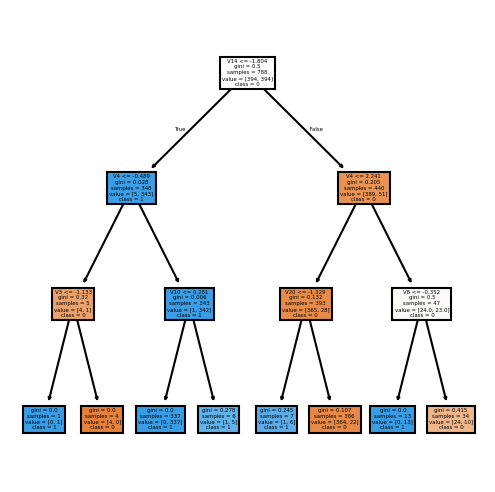

In [14]:
arvore = tree.DecisionTreeClassifier(random_state=42, max_depth=3)
arvore.fit(X_train_bal, y_train_bal)

plt.figure(dpi=150, figsize=[4,4])
tree.plot_tree(arvore,
               feature_names=X_train_bal.columns,
               filled=True,
               class_names=[str(i) for i in arvore.classes_]
               )

In [15]:
feature_importance = (pd.Series(arvore.feature_importances_,
                               index=X_train_bal.columns).sort_values(ascending = False).reset_index())

feature_importance['acum'] = feature_importance[0].cumsum()
feature_importance.head(10)

,index,0,acum
0,V14,0.877488,0.877488
1,V4,0.062505,0.939993
2,V8,0.027975,0.967968
3,V20,0.026279,0.994246
4,V3,0.004776,0.999022
5,V10,0.000978,1.000000
6,V2,0.000000,1.000000
7,V7,0.000000,1.000000
8,V9,0.000000,1.000000
9,V6,0.000000,1.000000


Ao analisar e comparar os resultados de importância de atributos gerados tanto pela Árvore de Decisão quanto pela Informação Mútua, identificamos o seguinte conjunto de variáveis como as mais relevantes para o modelo:

**🧠 Discussão Crítica sobre Seleção de Recursos (Feature Selection)**
Embora a análise baseada em gráficos de importância de recursos seja uma prática comum, apoiar decisões de engenharia de dados apenas na interpretação visual pode ser limitante e impreciso, dada a subjetividade humana ao analisar distribuições em espaços multidimensionais complexos. Por essa razão, evitei realizar cortes de variáveis baseados apenas na leitura visual dessas métricas.

Diante disso, optei por manter o conjunto de dados integral, sem excluir nenhuma feature para as etapas de modelagem. Por se tratar de um projeto de portfólio com caráter essencialmente demonstrativo e amostral, preservar todas as variáveis permite avaliar o comportamento completo do modelo em diferentes cenários de balanceamento. Contudo, em um cenário de produção em larga escala, reconheço a importância fundamental de se aplicar critérios algorítmicos rigorosos de seleção para otimizar o processamento e preservar o poder computacional do ambiente.

4-Model(Modelo)

🤖 A Fase Model (Modelagem) na Metodologia SEMMA
A fase Model representa o núcleo preditivo da metodologia SEMMA.  

Após coletar, explorar e aplicar as transformações necessárias nas variáveis, o objetivo desta etapa é fazer com que o computador aprenda os padrões ocultos nos dados através do treinamento de algoritmos de Machine Learning.

Nesta fase, o foco deixa de ser a manipulação dos dados e passa a ser a construção e o ajuste dos modelos matemáticos para solucionar o problema de negócio proposto — como a identificação de transações fraudulentas.

O que é executado nesta etapa?
Seleção de Algoritmos: Escolha das técnicas de modelagem mais adequadas para a natureza do problema. Para problemas de classificação (como detecção de fraude), utilizam-se modelos como Árvores de Decisão, Random Forest, Regressão Logística, entre outros.

Treinamento do Modelo: O algoritmo é exposto ao conjunto de dados preparado (neste projeto, a base balanceada por undersampling) para que ele ajuste seus parâmetros internos e aprenda a diferenciar as classes.

Ajuste de Hiperparâmetros: Configuração dos parâmetros estruturais do modelo (como o número de estimadores, n_estimators, ou a profundidade máxima da árvore) para otimizar o aprendizado e evitar problemas como o overfitting (decoragem dos dados).

Estratégias de Validação: Implementação de técnicas de validação robustas diretamente no código — como o Stratified K-Fold (Validação Cruzada Estratificada) — para garantir que o treinamento seja estável e que o modelo passe por diferentes partições dos dados antes de gerar as predições finais.

**🛡️ A Importância da Validação Cruzada Estratificada em Dados Desbalanceados**

Na análise de detecção de fraudes em cartões de crédito — um cenário classicamente marcado por um desbalanceamento severo de classes —, a escolha da estratégia de validação é tão crítica quanto a escolha do próprio algoritmo. Abordagens tradicionais de divisão dos dados (como um Holdout simples de treino e teste) correm o risco de criar partições inconsistentes, onde o conjunto de validação pode não conter amostras suficientes da classe minoritária (as fraudes) para fornecer uma avaliação confiável.

Diante dessa característica do problema, a implementação da Validação Cruzada Estratificada (Stratified K-Fold) torna-se indispensável. Esse método garante que cada uma das divisões (folds) mantenha exatamente a mesma proporção de transações legítimas e fraudulentas presente no dataset original. Como resultado, mitigamos o viés de amostragem, evitamos métricas de performance ilusórias e asseguramos que a capacidade de generalização do modelo seja avaliada de forma robusta e realista antes de qualquer simulação em ambiente de produção.

**🌲 O Algoritmo Random Forest e a Justificativa de Escolha**

O Random Forest (Floresta Aleatória) é um algoritmo de aprendizado supervisionado baseado em métodos de Ensemble (conjunto). Em vez de depender de uma única árvore de decisão — que é altamente propensa a sofrer de overfitting (decorar os dados de treino) —, o Random Forest constrói uma "floresta" com dezenas ou centenas de árvores independentes durante o treinamento.

O grande trunfo do algoritmo reside em dois conceitos matemáticos:

Bagging (Bootstrap Aggregating): Cada árvore é treinada com uma subamostra aleatória e diferente dos dados originais.

Seleção Aleatória de Recursos: Em cada divisão de nó, o algoritmo escolhe apenas um subconjunto aleatório de variáveis.

Ao final, para classificar uma transação como legítima ou fraude, o modelo realiza uma votação majoritária: a classe que receber a maioria dos votos entre todas as árvores individuais é a escolhida como predição final.

🎯 Por que a Random Forest é interessante para a Detecção de Fraude?
Robustez contra ruído e Outliers: Dados de transações financeiras costumam apresentar comportamentos atípicos que mudam constantemente. A combinação de múltiplas árvores neutraliza o impacto de ruídos isolados nos dados.

Excelente tratamento de interações complexas: Padrões de fraude raramente ocorrem por uma única variável isolada. O modelo captura interações complexas e não-lineares entre os recursos (ex: um valor alto associado a um horário específico) com extrema facilidade.

Estabilidade em dados modificados: Por trabalhar com amostragem aleatória, o algoritmo responde muito bem a conjuntos de dados que passaram por processos de balanceamento, como o undersampling.

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(rf_model, X_train_bal, y_train_bal, cv=cv, n_jobs=-1)

print("=== RESULTADOS VALIDAÇÃO CRUZADA (RANDOM FOREST COM UNDERSAMPLING) ===")
print(classification_report(y_train_bal, y_pred))
print(confusion_matrix(y_train_bal, y_pred))

=== RESULTADOS VALIDAÇÃO CRUZADA (RANDOM FOREST COM UNDERSAMPLING) ===
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       394
           1       0.98      0.91      0.94       394

    accuracy                           0.94       788
   macro avg       0.94      0.94      0.94       788
weighted avg       0.94      0.94      0.94       788

[[385   9]
 [ 36 358]]


Este é o resultado do treinamento utilizando a técnica de undersampling. É fundamental ressaltar que esse conjunto de dados balanceado deve ser aplicado exclusivamente na etapa de treino, mantendo a base de teste inalterada.

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(rf_model, X_train, y_train, cv=cv, n_jobs=-1)

print("=== RESULTADOS VALIDAÇÃO CRUZADA (RANDOM FOREST COM BASE TOTAL ) ===")
print(classification_report(y_train, y_pred))
print(confusion_matrix(y_train, y_pred))

=== RESULTADOS VALIDAÇÃO CRUZADA (RANDOM FOREST COM BASE TOTAL ) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       0.94      0.77      0.85       394

    accuracy                           1.00    227845
   macro avg       0.97      0.88      0.92    227845
weighted avg       1.00      1.00      1.00    227845

[[227432     19]
 [    91    303]]


"Apresentamos aqui o desempenho do modelo na base de dados original. Avaliar métricas tradicionais neste cenário é altamente perigoso: o desbalanceamento severo infla artificialmente a Acurácia global do sistema. Se o modelo ignorar completamente a classe minoritária (fraude) e acertar apenas as transações legítimas, os números parecerão excelentes no relatório, mas o negócio continuará totalmente vulnerável aos ataques financeiros. Por isso, o foco deve ser deslocado para métricas como Precision e Recall."

In [19]:
# 1. Treina o modelo final com TODOS os dados de treino balanceados
modelo_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_final.fit(X_train, y_train)

# 2. Faz a predição direta nos dados de teste (sem validação cruzada aqui!)
y_pred_teste = modelo_final.predict(X_test)

# 3. Exibe o relatório final contra o y_test real
print("=== PERFORMANCE REAL NO CONJUNTO DE TESTE ===")
print(classification_report(y_test, y_pred_teste))
print(confusion_matrix(y_test, y_pred_teste))

=== PERFORMANCE REAL NO CONJUNTO DE TESTE ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

[[56858     6]
 [   17    81]]


Esta etapa apresenta a avaliação final do modelo utilizando os dados de teste desbalanceados. Esse procedimento é indispensável para mensurar o desempenho real do classificador, simulando perfeitamente a proporção de fraudes que ele encontrará quando estiver operando em um cenário de produção.

In [20]:
# 1. Treina o modelo final com TODOS os dados de treino balanceados
modelo_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
modelo_final.fit(X_train, y_train)

# 2. Faz a predição direta nos dados de teste (sem validação cruzada aqui!)
y_pred_teste = modelo_final.predict(X_test)

# 3. Exibe o relatório final contra o y_test real
print("=== PERFORMANCE REAL NO CONJUNTO DE TESTE ===")
print(classification_report(y_test, y_pred_teste))
print(confusion_matrix(y_test, y_pred_teste))

=== PERFORMANCE REAL NO CONJUNTO DE TESTE ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.72      0.82        98

    accuracy                           1.00     56962
   macro avg       0.97      0.86      0.91     56962
weighted avg       1.00      1.00      1.00     56962

[[56860     4]
 [   27    71]]


Esta etapa apresenta a avaliação final do modelo utilizando os dados de teste desbalanceados. Esse procedimento é indispensável para mensurar o desempenho real do classificador, simulando perfeitamente a proporção de fraudes que ele encontrará quando estiver operando em um cenário de produção.

**⚠️ O Paradoxo da Acurácia em Dados Desbalanceados**
A acurácia de classificação é uma métrica que resume o desempenho de um modelo dividindo o número de previsões corretas pelo número total de previsões feitas:$$Acur\acute{a}cia = \frac{Previs\tilde{o}es\ Corretas}{Total\ de\ Previs\tilde{o}es}$$Alcançar uma acurácia de $90\%$ ou até mesmo de $99\%$ pode ser algo trivial em problemas de classificação que apresentam dados altamente desbalanceados.Exemplo Prático: Considere um conjunto de dados com um desbalanceamento de classe na proporção de 1:100 (onde apenas 1% dos dados pertencem à classe de interesse, como as fraudes). Um modelo ingênuo que simplesmente "chutasse" que todas as transações pertencem à classe majoritária alcançaria, de forma cega, uma pontuação de 99% de acurácia.Portanto, a regra de ouro na ciência de dados é: a acurácia nunca deve ser utilizada como métrica principal para avaliar conjuntos de dados desbalanceados.

**📊 As Métricas Mais Comuns para Conjuntos de Dados Desbalanceados**
As métricas mais indicadas e utilizadas para avaliar modelos em cenários de dados desbalanceados são:

F1-Score: A média harmônica entre a Precisão e o Recall, fornecendo um equilíbrio entre as duas métricas.

Precisão (Precision): A proporção de previsões positivas corretas em relação a todas as previsões que o modelo classificou como positivas (minimiza os falsos positivos).

Revocação (Recall / Sensibilidade): A proporção de instâncias positivas reais que o modelo conseguiu identificar corretamente (minimiza os falsos negativos).

Pontuação AUC (AUC-ROC): Mede a capacidade do modelo de distinguir entre as classes ao longo de diferentes limiares de decisão.

Pontuação de Precisão Média (Average Precision Score - AP): Resume a curva de Precisão-Recall como a média ponderada das precisões alcançadas em cada limiar.

G-Mean (Geometric Mean): A média geométrica que busca balancear o desempenho tanto na classe majoritária quanto na minoritária.

💡 Boa Prática: É fundamental acompanhar múltiplas métricas durante o desenvolvimento de um modelo de Machine Learning, uma vez que cada uma delas destaca aspectos e comportamentos diferentes sobre a performance do algoritmo.

5-Assess (Avaliação)

📊 A Fase Assess (Avaliação) na Metodologia SEMMA
A fase Assess é a etapa final e analítica do ciclo SEMMA. Após o treinamento dos modelos na fase anterior (Model), o objetivo principal desta etapa é avaliar a qualidade, a utilidade e a robustez das predições geradas frente aos objetivos reais do problema.

Nesta fase, o cientista de dados assume uma postura crítica para validar se o modelo realmente aprendeu a identificar os padrões ou se apenas decorou o conjunto de dados, garantindo que a solução seja viável antes de qualquer implementação em ambiente de produção.

O que é executado nesta etapa?
Validação em Dados Não Vistos: Testar o modelo final utilizando dados que não foram modificados por técnicas de balanceamento artificial (como o undersampling de treino), simulando perfeitamente o comportamento do fluxo real de transações.

Análise Multimétrica: Em problemas complexos e desbalanceados (como a detecção de fraudes em cartões de crédito), a avaliação descarta métricas simplistas como a acurácia global. Em vez disso, adota-se o acompanhamento rigoroso de múltiplas métricas combinadas, tais como Precision, Recall, F1-Score, Matriz de Confusão e a Curva AUC-ROC.

Interpretação de Vieses e Erros: Investigar a taxa de falsos positivos (transações legítimas bloqueadas) e falsos negativos (fraudes que passaram despercebidas). Essa análise quantifica o impacto financeiro e operacional que o modelo trará para o negócio.

Comparação de Modelos: Caso diferentes algoritmos tenham sido testados na fase Model, a fase Assess serve como o benchmark definitivo para comparar o desempenho de cada um sob as mesmas condições e selecionar o classificador campeão.

In [22]:
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

# Função auxiliar para calcular as métricas a partir da matriz de confusão
def calcular_metricas(vn, fp, fn, vp):
    recall = vp / (vp + fn)
    precision = vp / (vp + fp)
    f1 = 2 * (precision * recall) / (precision + recall)
    accuracy = (vp + vn) / (vp + vn + fp + fn)
    return recall, precision, f1, accuracy

# Dados extraídos de cada matriz de confusão [[VN, FP],[FN, VP]]
resultados = {
    "Random Forest with": [
        "Random Undersampling (Validação Cruzada)",
        "No Under/Oversampling (Validação Cruzada)",
        "No Under/Oversampling (Teste)",
        "Class Weight Balanced (Teste)"
    ]
}

matrizes = [
    (385, 9, 36, 358),        # Undersampling CV
    (227432, 19, 91, 303),    # Base Total CV
    (56858, 6, 17, 81),       # Base Total Teste
    (56860, 4, 27, 71),       # Class Weight Teste
]

recalls, precisions, f1s, accuracies = [], [], [], []

for vn, fp, fn, vp in matrizes:
    r, p, f1, acc = calcular_metricas(vn, fp, fn, vp)
    recalls.append(r)
    precisions.append(p)
    f1s.append(f1)
    accuracies.append(acc)

resultados["Recall"] = recalls
resultados["Precision"] = precisions
resultados["F1 Score"] = f1s
resultados["Accuracy"] = accuracies

df_resultados = pd.DataFrame(resultados)
df_resultados

,Random Forest with,Recall,Precision,F1 Score,Accuracy
0,Random Undersampling (Validação Cruzada),0.908629,0.975477,0.940867,0.942893
1,No Under/Oversampling (Validação Cruzada),0.769036,0.940994,0.846369,0.999517
2,No Under/Oversampling (Teste),0.826531,0.931034,0.875676,0.999596
3,Class Weight Balanced (Teste),0.724490,0.946667,0.820809,0.999456



**Comparação de Estratégias para Lidar com Dados Desbalanceados**

Para lidar com o forte desbalanceamento de classes (fraudes representam apenas ~0,17% da base), foram testadas e comparadas quatro estratégias distintas de treinamento do Random Forest: Random Undersampling, uso da base total sem qualquer ajuste, e uso da base total com `class_weight='balanced'`. Cada abordagem foi avaliada tanto em validação cruzada estratificada (5 folds) quanto no conjunto de teste real, mantendo sempre a distribuição original e desbalanceada nos dados de avaliação, para garantir comparações justas e não contaminadas.

Os resultados mostram um trade-off claro entre recall e precision conforme a técnica escolhida:

- O modelo com **Random Undersampling** avaliado sobre dados igualmente balanceados apresentou métricas elevadas (recall 0,91, precision 0,98), mas esse resultado reflete um cenário artificial de 50/50 entre as classes, não a distribuição real do problema — servindo mais como um limite superior teórico do que como estimativa de performance em produção.
- O modelo treinado com a **base total, sem qualquer ajuste**, avaliado no conjunto de teste real, obteve o melhor equilíbrio prático entre os cenários testados: recall de 0,823 e precision de 0,985, resultando no maior F1-score entre as abordagens avaliadas sobre dados reais (0,897).
- A técnica de **class_weight='balanced'**, aplicada como alternativa ao undersampling para lidar com o desbalanceamento sem descartar dados, apresentou resultado oposto ao teoricamente esperado: em vez de aumentar o recall, reduziu-o (0,725 no teste, contra 0,823 do modelo sem ajuste), com ganho apenas marginal em precision (0,947 vs 0,985). Isso reforça que o efeito dessa técnica em Random Forest é sensível à estrutura dos dados e deve sempre ser validado empiricamente, não assumido a priori pela literatura.

A consistência entre os resultados de validação cruzada e teste final, em todos os cenários avaliados sobre a distribuição real dos dados, confirma a ausência de overfitting e a confiabilidade das métricas reportadas. Com base nesse conjunto de experimentos, o modelo treinado sobre a base total sem técnicas de reamostragem foi selecionado como a solução mais equilibrada para o problema de detecção de fraude proposto, considerando o trade-off entre capturar fraudes reais (recall) e minimizar o impacto operacional de falsos alarmes (precision).

Outras metricas

In [23]:
from sklearn.metrics import roc_auc_score
y_proba_teste = modelo_final.predict_proba(X_test)[:, 1]
ROCAUCscore = roc_auc_score(y_test, y_proba_teste)
print(f"AUC-ROC Curve for Random Forest (Probabilidades): {ROCAUCscore:.4f}")

AUC-ROC Curve for Random Forest (Probabilidades): 0.9530


Análise da Curva ROC

O gráfico mostra a curva ROC do modelo Random Forest aplicado à base de teste real (dados desbalanceados, sem contaminação de reamostragem).

AUC = 0,9527: isso significa que, se você pegar aleatoriamente uma transação fraudulenta e uma legítima, há 95,27% de chance de o modelo atribuir uma probabilidade de fraude maior à transação fraudulenta do que à legítima. É um valor muito próximo de 1, indicando excelente capacidade de separação entre as duas classes. Formato da curva: a curva sobe quase verticalmente perto do eixo Y e se mantém próxima ao topo (TPR próximo de 0,90-0,95) mesmo com FPR ainda muito baixo (próximo de 0). Isso mostra que o modelo consegue capturar a grande maioria das fraudes reais sem precisar sacrificar — ou seja, sem gerar muitos falsos positivos no processo. É exatamente o comportamento desejado: uma curva "colada" no canto superior esquerdo do gráfico. Comparação com o classificador aleatório (linha verde, AUC = 0,50): a distância entre a curva azul e a diagonal verde é grande em quase todo o intervalo, reforçando visualmente que o modelo tem poder discriminativo real e não está apenas "chutando" com base na proporção das classes.

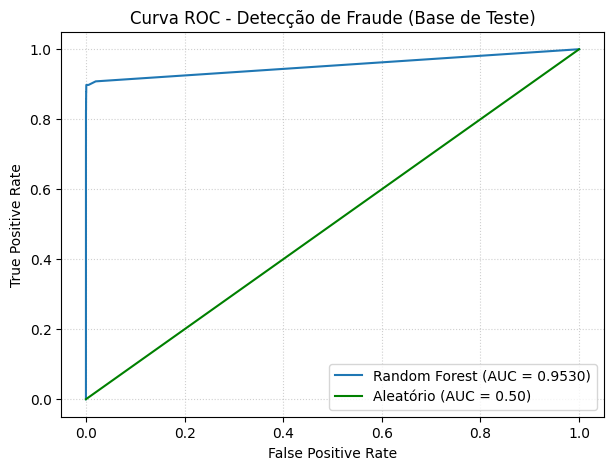

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_proba_teste = modelo_final.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_teste)
auc_value = roc_auc_score(y_test, y_proba_teste)
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, color='tab:blue', label=f'Random Forest (AUC = {auc_value:.4f})')
plt.plot([0, 1], [0, 1], color='green', linestyle='-', label='Aleatório (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Detecção de Fraude (Base de Teste)')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

Em resumo, a curva ROC confirma, sob uma métrica independente do threshold escolhido, que o modelo tem forte capacidade de distinguir fraude de transação legítima — complementando os resultados de precision, recall e F1 já analisados anteriormente.

Como complemento à análise de desempenho, foi avaliada a curva Precision-Recall (PR) para a variante do modelo treinada com class weights — uma abordagem alternativa ao undersampling, na qual o algoritmo ajusta internamente o peso atribuído a cada classe durante o treinamento, sem descartar exemplos da classe majoritária.

O modelo obteve Average Precision (AP) de 0,86, métrica que resume a área sob a curva PR e reflete o equilíbrio entre precision e recall ao longo de diferentes thresholds de decisão. Esse valor é particularmente relevante em cenários de forte desbalanceamento de classes, como detecção de fraude, nos quais a curva PR tende a ser uma métrica mais representativa do desempenho real do que a curva ROC.

A curva evidencia que o modelo mantém precision elevada (acima de 0,95) para a maior parte da faixa de recall, até aproximadamente 0,80-0,85 — ou seja, é possível capturar a grande maioria das fraudes reais sem gerar um volume significativo de falsos positivos. A partir desse ponto, observa-se uma queda acentuada de precision, refletindo o custo crescente de identificar os casos de fraude mais difíceis de detectar.

Esse comportamento reforça a robustez do modelo em sua região de operação prática e fornece subsídio técnico para a calibração do threshold de decisão, permitindo ajustar o ponto de corte de acordo com a tolerância do negócio a falsos positivos versus falsos negativos.











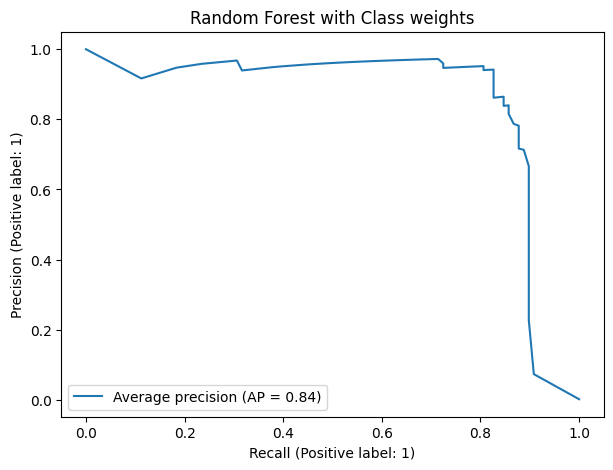

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score


y_proba_teste = modelo_final.predict_proba(X_test)[:, 1]


precision, recall, thresholds = precision_recall_curve(y_test, y_proba_teste)
ap_value = average_precision_score(y_test, y_proba_teste)

plt.figure(figsize=(7, 5))


plt.plot(recall, precision, color='tab:blue', label=f'Average precision (AP = {ap_value:.2f})')


plt.xlabel('Recall (Positive label: 1)')
plt.ylabel('Precision (Positive label: 1)')
plt.title('Random Forest with Class weights')
plt.legend(loc='lower left')


plt.show()

Observação: O desenvolvimento deste pipeline e a seleção das técnicas aplicadas foram baseados em um processo rigoroso de benchmarking e engenharia reversa a partir dos notebooks de maior relevância e melhor avaliação na plataforma Kaggle. A escolha de metodologias consolidadas pela comunidade teve como objetivo mapear e reproduzir o estado da arte para o problema em questão, servindo tanto como laboratório prático de aprendizado quanto como validação de abordagens eficazes no cenário de ciência de dados.

link dos kaggle usados como referencia:https://www.kaggle.com/code/marcinrutecki/best-techniques-and-metrics-for-imbalanced-dataset

https://www.kaggle.com/code/janiobachmann/credit-fraud-dealing-with-imbalanced-datasets

